# Milk Pooling and Blending

**Adapted, with thanks, from work by the late Jeffrey Kantor.**

This notebook is adapted from notebook 5.1, *Milk pooling and blending*, in the companion notebook collection for M. Postek, A. Zocca, J. Gromicho and J. Kantor, [*Hands-On Mathematical Optimization with Python*](https://mobook.github.io/MO-book/) (Cambridge University Press, 2025). Jeff Kantor was a colleague in this department; the example, the data and the framing of the three options are his.

The underlying problem is the canonical **pooling** benchmark of C. A. Haverly, "Studies of the behavior of recursion for the pooling problem," *ACM SIGMAP Bulletin* **25** (1978), 19--28.

```
MIT License

Copyright (c) 2022 Jeffrey Kantor

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```

**What is different here.** The models are rewritten with named `pyo.Set` and `pyo.Param` components so that the Pyomo code reads as the set-notation model in the lecture notes, the solver is `ipopt` throughout rather than `appsi_highs`, and the convex (McCormick) relaxation is left to the global optimization lecture. Two typographical errors in the source notebook's mathematics are corrected: its blending constraints are printed with the summation running over the cross product $L \times C$ inside a constraint that is already quantified for all $c \in C$, and the sum must run over $l \in L$ alone. Its Pyomo code is correct as written.


In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/pyomo_results.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

# Extract / archive / save-the-figure plumbing, shared with the lecture handouts.
import pyomo_results as pyr


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent

# The source data is scale-free: milk is measured in "units" and priced per unit.
# Pyomo's unit library has neither, so declare both. Fat content stays
# dimensionless -- it is a mass fraction, kg of fat per kg of milk.
u.load_definitions_from_strings(["USD = [currency]", "milk = [milk]"])

## Problem description

A bulk distributor supplies custom milk blends to several customers. Each customer specifies a minimum fat content, pays a fixed price per unit, and will buy no more than a stated maximum. The distributor sources raw milk from local farms, each producing milk of known fat content at a known cost.

The distributor has found cheaper raw milk at some **remote** farms. But it owns only one truck with a single tank for the remote route, so milk from the remote farms must be mixed in that tank before transport. That creates a **pool** of uniform composition, which is then blended with local milk to meet each customer's requirement.

Three options:

1. **Business as usual** --- local farms only.
2. **Buy a second truck** --- keep each remote farm's milk separate, so everything blends freely.
3. **Pool the remote farms** --- one truck, one tank, one composition.

Options 1 and 2 are linear programs. Option 3 is not, and that is the point of the example.

```{note}
The source data does not name the physical unit of milk. Amounts are in unnamed "units", costs and prices are per unit, and fat content is a mass fraction. The units below are annotated as such.
```


In [3]:
customers = pd.DataFrame(
    {
        "Customer 1": {"min_fat": 0.045, "price": 52.0, "demand": 6000.0},
        "Customer 2": {"min_fat": 0.030, "price": 48.0, "demand": 2500.0},
        "Customer 3": {"min_fat": 0.040, "price": 50.0, "demand": 4000.0},
    }
).T

suppliers = pd.DataFrame(
    {
        "Farm A": {"fat": 0.045, "cost": 45.0, "location": "local"},
        "Farm B": {"fat": 0.030, "cost": 42.0, "location": "local"},
        "Farm C": {"fat": 0.033, "cost": 37.0, "location": "remote"},
        "Farm D": {"fat": 0.050, "cost": 45.0, "location": "remote"},
    },
).T

# Farm and customer names
local_farms = suppliers.index[suppliers["location"] == "local"].tolist()
remote_farms = suppliers.index[suppliers["location"] == "remote"].tolist()
all_farms = local_farms + remote_farms
customer_names = customers.index.tolist()

# Problem data as plain dictionaries, keyed by farm or customer name

# Fat fraction of the milk from farm s, phi_s [dimensionless]
fat = suppliers["fat"].astype(float).to_dict()

# Purchase cost per unit from farm s, kappa_s [USD/milk]
cost = suppliers["cost"].astype(float).to_dict()

# Price paid per unit by customer k, pi_k [USD/milk]
price = customers["price"].astype(float).to_dict()

# Maximum demand of customer k, d_k [milk]
demand = customers["demand"].astype(float).to_dict()

# Minimum fat fraction customer k accepts, phi_min_k [dimensionless]
min_fat = customers["min_fat"].astype(float).to_dict()

print("Customers")
display(customers)

print("Suppliers")
display(suppliers)

Customers


,min_fat,price,demand
Customer 1,0.045,52.0,6000.0
Customer 2,0.030,48.0,2500.0
Customer 3,0.040,50.0,4000.0


Suppliers


,fat,cost,location
Farm A,0.045,45.0,local
Farm B,0.03,42.0,local
Farm C,0.033,37.0,remote
Farm D,0.05,45.0,remote


## Options 1 and 2 --- blending only, no pool

Let $\mathcal{S}$ be a set of farms and $\mathcal{K}$ the customers. The decision variable $z_{s,k}$ is the amount of milk from farm $s$ blended into the delivery to customer $k$.

$$
\begin{align}
\max_{z} \quad & \sum_{s \in \mathcal{S}} \sum_{k \in \mathcal{K}} (\pi_k - \kappa_s) z_{s,k} && \text{profit} \\
\text{s.t.} \quad & \sum_{s \in \mathcal{S}} z_{s,k} \leq d_k && \forall k \in \mathcal{K} \quad \text{demand} \\
& \sum_{s \in \mathcal{S}} \phi_s z_{s,k} \geq \phi^{\min}_k \sum_{s \in \mathcal{S}} z_{s,k} && \forall k \in \mathcal{K} \quad \text{blend quality} \\
& z_{s,k} \geq 0
\end{align}
$$

Here $\phi_s$ is the fat fraction of farm $s$'s milk, $\kappa_s$ its cost per unit, $\pi_k$ the price customer $k$ pays, $d_k$ its maximum demand and $\phi^{\min}_k$ its minimum acceptable fat fraction. Option 1 takes $\mathcal{S} = \mathcal{L}$, the local farms. Option 2 takes $\mathcal{S} = \mathcal{L} \cup \mathcal{R}$, all of them.

Every term is linear, so this is a **linear program**.


**Units.** Milk here is measured in generic *units*, so the notebook declares a `milk`
unit and a `USD` currency and hangs them on every `Param` and `Var`. Fat content stays
dimensionless, because it is a mass fraction. Both builders end with
`assert_units_consistent`, which is the part that earns the declaration: it is what
would catch a price or a cost mixed into a constraint that balances amounts of
milk. It cannot catch everything: fat content is dimensionless, so a fat balance
and a milk balance carry the same units.

In [4]:
def create_blending_model(farms):
    """Create the linear blending model (no pool) in Pyomo

    Arguments:
        farms: list of farm names to source from

    Returns:
        m: Pyomo concrete model
    """

    m = pyo.ConcreteModel("Milk blending")

    # Farms, S in the notes
    m.S = pyo.Set(initialize=farms)

    # Customers, K in the notes
    m.K = pyo.Set(initialize=customer_names)

    # Fat fraction of the milk from farm s, phi_s [dimensionless]
    m.fat = pyo.Param(m.S, initialize={s: fat[s] for s in farms})

    # Purchase cost per unit from farm s, kappa_s [USD/milk]
    m.cost = pyo.Param(
        m.S, initialize={s: cost[s] for s in farms}, units=u.USD / u.milk
    )

    # Price paid per unit by customer k, pi_k [USD/milk]
    m.price = pyo.Param(m.K, initialize=price, units=u.USD / u.milk)

    # Maximum demand of customer k, d_k [milk]
    m.demand = pyo.Param(m.K, initialize=demand, units=u.milk)

    # Minimum fat fraction customer k accepts, phi_min_k [dimensionless]
    m.min_fat = pyo.Param(m.K, initialize=min_fat)

    # Milk shipped from farm s to customer k, z_{s,k} [milk]
    m.z = pyo.Var(m.S, m.K, domain=pyo.NonNegativeReals, units=u.milk)

    # Maximize profit [USD]
    @m.Objective(sense=pyo.maximize)
    def profit(b):
        return sum((b.price[k] - b.cost[s]) * b.z[s, k] for s in b.S for k in b.K)

    # Deliveries cannot exceed each customer's demand [milk]
    @m.Constraint(m.K)
    def demand_limit(b, k):
        return sum(b.z[s, k] for s in b.S) <= b.demand[k]

    # Linear blending: each delivery meets its fat spec [milk]
    @m.Constraint(m.K)
    def blend_quality(b, k):
        return sum(b.fat[s] * b.z[s, k] for s in b.S) >= b.min_fat[k] * sum(
            b.z[s, k] for s in b.S
        )

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(m)

    return m

In [5]:
solver = pyo.SolverFactory("ipopt")


def report_blending(m, title):
    results = solver.solve(m)
    assert pyo.check_optimal_termination(results), f"Solve failed for {title}"
    print(f"{title}: profit = {pyo.value(m.profit):,.2f}\n")

    rows = []
    for k in m.K:
        row = {s: pyo.value(m.z[s, k]) for s in m.S}
        total = sum(row.values())
        row["Total"] = total
        row["fat delivered"] = (
            sum(pyo.value(m.z[s, k]) * pyo.value(m.fat[s]) for s in m.S) / total
            if total > 0
            else np.nan
        )
        row["min_fat"] = pyo.value(m.min_fat[k])
        rows.append(row)
    display(pd.DataFrame(rows, index=list(m.K)).round(4))
    return pyo.value(m.profit)


profit_1 = report_blending(
    create_blending_model(local_farms), "Option 1, local farms only"
)

Option 1, local farms only: profit = 81,000.00



,Farm A,Farm B,Total,fat delivered,min_fat
Customer 1,6000.0001,0.0000,6000.0001,0.045,0.045
Customer 2,-0.0000,2500.0000,2500.0000,0.030,0.030
Customer 3,2666.6667,1333.3333,4000.0000,0.040,0.040


In [6]:
profit_2 = report_blending(
    create_blending_model(all_farms), "Option 2, all farms, one truck each"
)

Option 2, all farms, one truck each: profit = 122,441.18



,Farm A,Farm B,Farm C,Farm D,Total,fat delivered,min_fat
Customer 1,-0.0,-0.0,1764.7059,4235.2942,6000.0001,0.045,0.045
Customer 2,-0.0,-0.0,2500.0000,-0.0000,2500.0000,0.033,0.030
Customer 3,-0.0,-0.0,2352.9412,1647.0588,4000.0000,0.040,0.040


Sourcing from the remote farms is worth a great deal --- but Option 2 needs a second truck to keep the two remote supplies separated in transit. Note also that the local farms are displaced entirely, and that Customer 2 is delivered milk richer than it requires. That is **product giveaway**: the optimizer hands over quality because the alternative costs more.


## Option 3 --- the pooling problem

Only one truck is available for the remote route, so purchases from the remote farms are combined into a single pool of uniform composition, transported, and then blended with local milk.

This is the **$p$-parameterization** of the pooling problem: the pool composition is itself a decision variable, $p$.

**Sets.** $\mathcal{L}$ local farms; $\mathcal{R}$ remote farms; $\mathcal{K}$ customers.

**Variables.** $z_{l,k}$, local milk shipped from $l \in \mathcal{L}$ to customer $k$; $x_r$, milk bought from remote farm $r$; $y_k$, pooled milk delivered to customer $k$; and $p$, the fat fraction *of the pool*.

$$
\begin{align}
\max_{x, y, z, p} \quad & \sum_{l \in \mathcal{L}} \sum_{k \in \mathcal{K}} (\pi_k - \kappa_l) z_{l,k} + \sum_{k \in \mathcal{K}} \pi_k y_k - \sum_{r \in \mathcal{R}} \kappa_r x_r && \text{profit} \\
\text{s.t.} \quad & \sum_{l \in \mathcal{L}} z_{l,k} + y_k \leq d_k && \forall k \in \mathcal{K} \quad \text{demand} \\
& \sum_{r \in \mathcal{R}} x_r = \sum_{k \in \mathcal{K}} y_k && \text{pool balance} \\
& \sum_{r \in \mathcal{R}} \phi_r x_r = \underbrace{p \sum_{r \in \mathcal{R}} x_r}_{\textbf{bilinear}} && \text{pool fat balance} \\
& \underbrace{p\, y_k}_{\textbf{bilinear}} + \sum_{l \in \mathcal{L}} \phi_l z_{l,k} \geq \phi^{\min}_k \Big( \sum_{l \in \mathcal{L}} z_{l,k} + y_k \Big) && \forall k \in \mathcal{K} \quad \text{blend quality}
\end{align}
$$

Every variable is nonnegative, $y_k \leq d_k$, and $p$ is bounded below and above by the smallest and largest fat fractions among the remote farms --- a pool cannot be richer than its richest input.

The pool fat balance can be written either as $p \sum_{r \in \mathcal{R}} x_r$, as above and as the Pyomo code below does, or as $p \sum_{k \in \mathcal{K}} y_k$. The two agree on the feasible set, because the pool balance constraint immediately above forces $\sum_{r} x_r = \sum_{k} y_k$.

The last two constraints contain **bilinear** terms: a product of the composition variable $p$ with a flow variable. A bilinear term is smooth and differentiable everywhere, and irreducibly **nonconvex**. Unlike an absolute value, no change of variables removes it.

```{note}
Notation warning: $p$ here is a *composition*, not a search direction. The symbol is the pooling literature's own and is worth keeping, but elsewhere in this course $p$ is a step.
```


In [7]:
def create_pooling_model():
    """Create the bilinear milk pooling model in Pyomo

    Returns:
        m: Pyomo concrete model
    """

    m = pyo.ConcreteModel("Milk pooling")

    # Local farms, L in the notes
    m.L = pyo.Set(initialize=local_farms)

    # Remote farms, R in the notes
    m.R = pyo.Set(initialize=remote_farms)

    # All farms, L union R
    m.S = m.L | m.R

    # Customers, K in the notes
    m.K = pyo.Set(initialize=customer_names)

    # Fat fraction of the milk from farm s, phi_s [dimensionless]
    m.fat = pyo.Param(m.S, initialize=fat)

    # Purchase cost per unit from farm s, kappa_s [USD/milk]
    m.cost = pyo.Param(m.S, initialize=cost, units=u.USD / u.milk)

    # Price paid per unit by customer k, pi_k [USD/milk]
    m.price = pyo.Param(m.K, initialize=price, units=u.USD / u.milk)

    # Maximum demand of customer k, d_k [milk]
    m.demand = pyo.Param(m.K, initialize=demand, units=u.milk)

    # Minimum fat fraction customer k accepts, phi_min_k [dimensionless]
    m.min_fat = pyo.Param(m.K, initialize=min_fat)

    # Local milk shipped from farm l to customer k, z_{l,k} [milk]
    m.z = pyo.Var(m.L, m.K, domain=pyo.NonNegativeReals, units=u.milk)

    # Milk bought from remote farm r, x_r [milk]
    m.x = pyo.Var(m.R, domain=pyo.NonNegativeReals, units=u.milk)

    # Pooled milk delivered to customer k, y_k [milk]
    m.y = pyo.Var(m.K, bounds=lambda m, k: (0, m.demand[k]), units=u.milk)

    # A pool cannot be richer than its richest input, nor leaner than its
    # leanest.
    # Fat fraction of the pool, p [dimensionless]
    m.p = pyo.Var(
        bounds=(min(fat[r] for r in remote_farms), max(fat[r] for r in remote_farms))
    )

    # Maximize profit [USD]
    @m.Objective(sense=pyo.maximize)
    def profit(b):
        return (
            sum((b.price[k] - b.cost[l]) * b.z[l, k] for l in b.L for k in b.K)
            + sum(b.price[k] * b.y[k] for k in b.K)
            - sum(b.cost[r] * b.x[r] for r in b.R)
        )

    # Local milk plus pooled milk cannot exceed each customer's demand [milk]
    @m.Constraint(m.K)
    def demand_limit(b, k):
        return sum(b.z[l, k] for l in b.L) + b.y[k] <= b.demand[k]

    # What is bought from the remote farms is what leaves the pool [milk]
    @m.Constraint()
    def pool_balance(b):
        return sum(b.x[r] for r in b.R) == sum(b.y[k] for k in b.K)

    # Fat into the pool equals fat out. BILINEAR. [milk]
    @m.Constraint()
    def pool_quality(b):
        return sum(b.fat[r] * b.x[r] for r in b.R) == b.p * sum(b.x[r] for r in b.R)

    # Each delivery meets its fat spec. BILINEAR. [milk]
    @m.Constraint(m.K)
    def blend_quality(b, k):
        fat_delivered = b.p * b.y[k] + sum(b.fat[l] * b.z[l, k] for l in b.L)
        milk_delivered = sum(b.z[l, k] for l in b.L) + b.y[k]
        return fat_delivered >= b.min_fat[k] * milk_delivered

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(m)

    return m

In [8]:
def report_pooling(m, title):
    print(f"{title}")
    print(f"  pool composition p = {pyo.value(m.p):6.4f}")
    print(f"  profit             = {pyo.value(m.profit):,.2f}\n")

    rows = []
    for s in m.S:
        row = {"fat": pyo.value(m.fat[s]), "cost": pyo.value(m.cost[s])}
        for k in m.K:
            row[k] = pyo.value(m.z[s, k]) if s in m.L else 0.0
        row["Pool"] = pyo.value(m.x[s]) if s in m.R else 0.0
        rows.append(row)
    print("  Supplier report")
    display(pd.DataFrame(rows, index=list(m.S)).round(4))

    rows = []
    for k in m.K:
        row = {"min_fat": pyo.value(m.min_fat[k]), "demand": pyo.value(m.demand[k])}
        for l in m.L:
            row[l] = pyo.value(m.z[l, k])
        row["Pool"] = pyo.value(m.y[k])
        total = sum(pyo.value(m.z[l, k]) for l in m.L) + pyo.value(m.y[k])
        row["Total"] = total
        row["fat delivered"] = (
            (
                sum(pyo.value(m.z[l, k]) * pyo.value(m.fat[l]) for l in m.L)
                + pyo.value(m.y[k]) * pyo.value(m.p)
            )
            / total
            if total > 0
            else np.nan
        )
        rows.append(row)
    print("  Customer report")
    display(pd.DataFrame(rows, index=list(m.K)).round(4))

### Solve it twice

`bound_frac` is an Ipopt option that controls only how far inside its bounds the solver places the *initial point*. It changes nothing about the model. Solve the same model with two values of it.


In [9]:
nlp_solver = pyo.SolverFactory("ipopt")

nlp_solver.options["bound_frac"] = 0.01
m_a = create_pooling_model()
results = nlp_solver.solve(m_a)
assert pyo.check_optimal_termination(results), "Solve failed"
report_pooling(m_a, "Option 3, pooled, bound_frac = 0.01")

Option 3, pooled, bound_frac = 0.01
  pool composition p = 0.0330
  profit             = 102,833.33

  Supplier report


,fat,cost,Customer 1,Customer 2,Customer 3,Pool
Farm A,0.045,45.0,6000.0001,-0.0,2333.3334,0.0000
Farm B,0.030,42.0,-0.0000,0.0,-0.0000,0.0000
Farm C,0.033,37.0,0.0000,0.0,0.0000,4166.6667
Farm D,0.050,45.0,0.0000,0.0,0.0000,-0.0000


  Customer report


,min_fat,demand,Farm A,Farm B,Pool,Total,fat delivered
Customer 1,0.045,6000.0,6000.0001,-0.0,0.0000,6000.0001,0.045
Customer 2,0.030,2500.0,-0.0000,0.0,2500.0000,2500.0000,0.033
Customer 3,0.040,4000.0,2333.3334,-0.0,1666.6667,4000.0000,0.040


In [10]:
nlp_solver.options["bound_frac"] = 0.5
m_b = create_pooling_model()
results = nlp_solver.solve(m_b)
assert pyo.check_optimal_termination(results), "Solve failed"
report_pooling(m_b, "Option 3, pooled, bound_frac = 0.5")

Option 3, pooled, bound_frac = 0.5
  pool composition p = 0.0450
  profit             = 101,392.16

  Supplier report


,fat,cost,Customer 1,Customer 2,Customer 3,Pool
Farm A,0.045,45.0,0.0,-0.0,-0.0000,0.0000
Farm B,0.030,42.0,-0.0,2500.0,1333.3333,0.0000
Farm C,0.033,37.0,0.0,0.0,0.0000,2549.0196
Farm D,0.050,45.0,0.0,0.0,0.0000,6117.6471


  Customer report


,min_fat,demand,Farm A,Farm B,Pool,Total,fat delivered
Customer 1,0.045,6000.0,0.0,-0.0000,6000.0001,6000.0001,0.045
Customer 2,0.030,2500.0,-0.0,2500.0000,-0.0000,2500.0000,0.030
Customer 3,0.040,4000.0,-0.0,1333.3333,2666.6667,4000.0000,0.040


<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;">
<b>Activity</b>: Same model, same solver, same tolerances. One option changed, and it only affects where the solver starts. Which of the two answers is right, and how would you know?
</div>


### Why: fix $p$ and look

If $p$ is held fixed, every remaining constraint is linear and the problem is an LP. Sweeping $p$ over its range and solving the LP at each value shows the profit as a function of the pool composition. It has **three** local maxima.

It is tempting to say that Ipopt converges to whichever one it starts nearest. That is *false*, and this model is the counterexample: reading Ipopt's pushed-in initial point back with `max_iter = 0`, `bound_frac = 0.5` starts $p$ at $0.0415$ and `bound_frac = 0.4` starts it at $0.0398$ --- essentially *on* the local maximum near $0.040$ --- and both converge to $0.045$. The reason is the teachable part: `bound_frac` pushes *every* variable off its bounds, so the twelve-vector the barrier method actually starts from is nowhere near the local solution whose $p$ value it happens to share. **Proximity in one coordinate predicts nothing.**


In [11]:
# ---------- SOLVE ----------------------------------------------------------
# Fix p and every remaining term is linear: what is left is an LP, one per
# value of p. Build the Pyomo model ONCE and re-fix p between solves --
# rebuilding it at every grid point costs far more than the solves do.
#
# The grid is split at the two customer fat requirements that fall strictly
# inside the range of p, because the profit is not continuous there. Each
# segment stops just short of its right-hand breakpoint, so nothing draws a
# line across a jump that is not there.

# The model's own bounds on p: a pool is no richer than its richest input and
# no leaner than its leanest.
p_lo = min(fat[r] for r in remote_farms)  # 0.033
p_hi = max(fat[r] for r in remote_farms)  # 0.050

# Derived from the data, not hard-coded, so the sweep follows the instance if
# the instance ever changes.
breaks = sorted({v for v in min_fat.values() if p_lo < v < p_hi})  # 0.040, 0.045

m_sweep = create_pooling_model()


def profit_at_fixed_p(p_value):
    """Solve the pooling model with the pool composition p fixed. This is an LP."""
    m_sweep.p.fix(p_value)
    status = solver.solve(m_sweep)
    if not pyo.check_optimal_termination(status):
        return np.nan
    return pyo.value(m_sweep.profit)


eps = 1e-7
edges = [p_lo] + breaks + [p_hi]
segments = []
for lo, hi in zip(edges[:-1], edges[1:]):
    grid = np.linspace(lo, hi - eps, 400)
    segments.append((grid, np.array([profit_at_fixed_p(p) for p in grid])))

# The right-hand end of the last segment IS attained, so include it.
grid, vals = segments[-1]
segments[-1] = (np.append(grid, p_hi), np.append(vals, profit_at_fixed_p(p_hi)))

# The three local maxima: the lower bound on p, and each breakpoint.
maxima = [(p, profit_at_fixed_p(p)) for p in [p_lo] + breaks]

# The limit from the left at the jump -- a value the profit approaches and
# never attains.
jump_limit = profit_at_fixed_p(breaks[-1] - eps)

# Where did the two Ipopt runs above START? `bound_frac` pushes every variable
# off its bounds before the first iteration; read that pushed-in point back by
# solving with max_iter = 0. Pyomo warns that the solve did not converge --
# it was never meant to.
def initial_p(bound_frac):
    """Ipopt's pushed-in initial value of p, for a given bound_frac."""
    probe = pyo.SolverFactory("ipopt")
    probe.options["bound_frac"] = bound_frac
    probe.options["max_iter"] = 0
    m = create_pooling_model()
    probe.solve(m)
    return pyo.value(m.p)


ipopt_runs = [
    {
        "label": "bound_frac = 0.01",
        "bound_frac": 0.01,
        "p_start": initial_p(0.01),
        "p_land": pyo.value(m_a.p),
        "profit_land": pyo.value(m_a.profit),
    },
    {
        "label": "bound_frac = 0.5",
        "bound_frac": 0.5,
        "p_start": initial_p(0.5),
        "p_land": pyo.value(m_b.p),
        "profit_land": pyo.value(m_b.profit),
    },
]

print(f"{sum(len(g) for g, _ in segments) + 5} LP solves")
for p_star, f_star in maxima:
    print(f"  local maximum at p = {p_star:.3f}:  profit = {f_star:12,.2f}")
for run in ipopt_runs:
    print(
        f"  {run['label']:<20} starts at p = {run['p_start']:.6f}"
        f" and lands at p = {run['p_land']:.4f}"
    )

model.name="Milk pooling";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="Milk pooling";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


1206 LP solves
  local maximum at p = 0.033:  profit =   102,833.33
  local maximum at p = 0.040:  profit =   100,088.24
  local maximum at p = 0.045:  profit =   101,392.16
  bound_frac = 0.01    starts at p = 0.033170 and lands at p = 0.0330
  bound_frac = 0.5     starts at p = 0.041500 and lands at p = 0.0450


In [12]:
# ---------- EXTRACT --------------------------------------------------------
# Pyomo objects -> plain Python. After this cell nothing below touches a model
# or a solver: the plotting cell reads `results` and nothing else, so it can be
# re-run as many times as it takes to get the labels off each other without
# paying for 1205 solves again.

results = {
    "bounds": {"p_lo": float(p_lo), "p_hi": float(p_hi)},
    "breaks": [float(b) for b in breaks],
    # One table per continuous piece of the profit function.
    "segments": [
        pyr.table(pd.DataFrame({"p": g, "profit": v})) for g, v in segments
    ],
    "maxima": pyr.table(
        pd.DataFrame(maxima, columns=["p", "profit"])
    ),
    # The value approached from the left at the jump, and never attained.
    "jump_limit": {"p": float(breaks[-1]), "profit": float(jump_limit)},
    "ipopt_runs": pyr.table(pd.DataFrame(ipopt_runs)),
}

# ---------- ARCHIVE --------------------------------------------------------
# figures/results/pooling-profit-vs-p.json, committed to the repo, so a change
# to the house style can redraw this figure with no solver installed.
# `source_tag` points at the model cell above, so scripts/check_results_fresh.py
# can tell you when the model has changed and these numbers have not. A no-op
# on Colab, where there is nothing to commit to.
pyr.save_results(
    "pooling-profit-vs-p",
    results,
    notebook="notebooks/1-dev/Milk-Pooling.ipynb",
    source_tag="handout:milk-pooling-model",
    description="Profit of the milk pooling model as a function of the pool "
    "composition p, swept as an LP over three continuous pieces, with the "
    "three local maxima and the two Ipopt runs marked.",
    solver="Ipopt via Pyomo",
)

[pyomo_results] wrote figures/results/pooling-profit-vs-p.json


/Users/adowling/opt/anaconda3/envs/optimization_fall2026/lib/python3.13/site-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)


'/Users/adowling/DowlingLab/Teaching/optimization/figures/results/pooling-profit-vs-p.json'

[pyomo_results] wrote media/figures/pooling-profit-vs-p.png and .pdf


'/Users/adowling/DowlingLab/Teaching/optimization/media/figures/pooling-profit-vs-p.png'

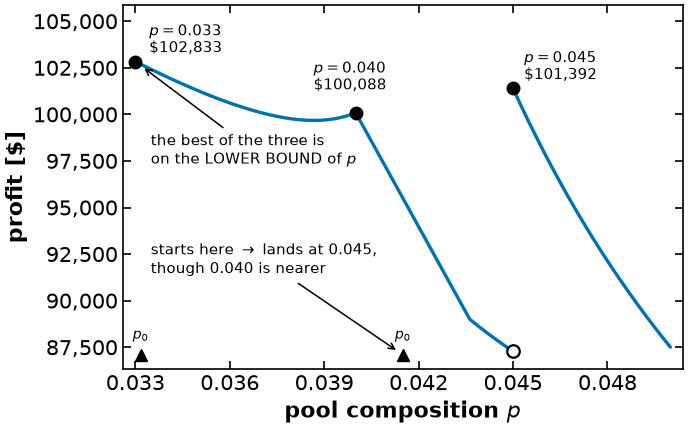

In [13]:
# The PLOTTING function: it takes the extracted results, not the Pyomo model.
#
# This cell is tagged `figure:pooling-profit-vs-p`, which makes it the single
# source of the figure in the lecture handout. See figures/README.md;
# figures/render_from_notebook.py re-runs exactly this cell against the
# archived JSON when the house style changes, so there is no second copy of the
# plotting code anywhere.


def plot_pooling_profit_vs_p(results):
    """Profit against the pool composition p: three local maxima, no smoothness.

    Two things the usual phrasing -- "three local maxima near 0.033, 0.040 and
    0.045" -- does not say, and the figure shows:

    * The BEST of the three sits ON the lower bound of p. It is not found by
      setting a derivative to zero.
    * The profit is neither smooth nor even continuous. The kink at p = 0.040
      is Customer 3's minimum fat fraction and the JUMP at p = 0.045 is
      Customer 1's: at p = 0.045 the pool on its own can finally satisfy the
      largest, best-paying customer, and 6,000 units of demand become servable
      in one step. It is drawn as a discontinuity -- two segments, an open
      circle for the limit from the left, a filled one for the value attained
      -- because joining them with a line would draw a claim that is false.

    The two Ipopt runs are marked where they START, on the axis. The second
    starts nearer the maximum at 0.040 than the one at 0.045 and walks to
    0.045 anyway: the starting point is twelve numbers, not one.

    Greyscale: the profit curve is the only series. Nothing is keyed by colour.
    """
    segments = [pyr.as_dataframe(t) for t in results["segments"]]
    maxima = pyr.as_dataframe(results["maxima"])
    runs = pyr.as_dataframe(results["ipopt_runs"])
    p_lo = results["bounds"]["p_lo"]
    p_hi = results["bounds"]["p_hi"]
    jump = results["jump_limit"]

    blue = "#0072B2"  # Okabe-Ito

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for seg in segments:
        ax.plot(seg["p"], seg["profit"], color=blue, linestyle="-", linewidth=2.4)

    # --- the three local maxima -------------------------------------------
    for _, row in maxima.iterrows():
        ax.plot([row["p"]], [row["profit"]], marker="o", markersize=9,
                color="black", zorder=5, linestyle="none")

    # Open circle: the limit from the left at the jump, which is NOT attained.
    ax.plot([jump["p"]], [jump["profit"]], marker="o", markersize=9,
            markerfacecolor="white", markeredgecolor="black",
            markeredgewidth=1.6, linestyle="none", zorder=5)

    # --- direct labels on the maxima --------------------------------------
    label_offsets = [(10, 4), (-4, 14), (8, 4)]
    label_align = ["left", "center", "left"]
    for (_, row), (dx, dy), ha in zip(maxima.iterrows(), label_offsets, label_align):
        ax.annotate(
            # {,} rather than a bare comma: mathtext sets a bare comma as
            # punctuation and inserts a space, giving "$102, 833".
            f"$p = {row['p']:.3f}$\n$\\${row['profit']:,.0f}$".replace(",", "{,}"),
            xy=(row["p"], row["profit"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=11,
            ha=ha,
            va="bottom",
            linespacing=1.05,
        )

    ax.annotate(
        "the best of the three is\non the LOWER BOUND of $p$",
        xy=(p_lo, maxima["profit"].iloc[0]),
        xytext=(0.05, 0.60),
        textcoords="axes fraction",
        fontsize=11,
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="->", color="black", linewidth=1.1,
                        shrinkB=8.0),
    )

    # --- where the two Ipopt runs started, and where they went -------------
    y_lo, y_hi = ax.get_ylim()
    tick = y_lo + 0.035 * (y_hi - y_lo)
    for _, run in runs.iterrows():
        ax.plot([run["p_start"]], [tick], marker="^", markersize=8,
                color="black", linestyle="none", clip_on=False, zorder=6)
        ax.annotate("$p_0$", xy=(run["p_start"], tick), xytext=(0, 9),
                    textcoords="offset points", fontsize=10, ha="center",
                    va="bottom")
    ax.annotate(
        "starts here $\\rightarrow$ lands at $0.045$,\n"
        "though $0.040$ is nearer",
        xy=(runs["p_start"].iloc[1], tick),
        xytext=(0.05, 0.30),
        textcoords="axes fraction",
        fontsize=11,
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="->", color="black", linewidth=1.1,
                        shrinkB=6.0),
    )

    # Headroom at the top for the two labels that sit above their markers.
    y_lo2, y_hi2 = ax.get_ylim()
    ax.set_ylim(y_lo2, y_hi2 + 0.13 * (y_hi2 - y_lo2))

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _pos: f"{v:,.0f}")
    )
    ax.set_xlabel("pool composition $p$")
    ax.set_ylabel("profit [\\$]")
    ax.set_xlim(p_lo - 0.0004, p_hi + 0.0004)
    ax.set_xticks(np.arange(0.033, 0.0501, 0.003))

    fig.tight_layout()
    return fig


fig = plot_pooling_profit_vs_p(results)

# Write media/figures/pooling-profit-vs-p.{png,pdf} -- what the lecture handout
# \includegraphics. A no-op on Colab, where there is no repo to write to.
pyr.save_figure(fig, "pooling-profit-vs-p")

## Comparing the three options


In [14]:
summary = pd.DataFrame(
    [
        ["1. Local farms only", "LP", profit_1, "leaves money on the table"],
        ["2. All farms, one truck each", "LP", profit_2, "needs a second truck"],
        ["3. Remote farms pooled", "bilinear NLP", pyo.value(m_a.profit), "nonconvex"],
    ],
    columns=["Option", "Model class", "Profit", "Catch"],
)
display(summary.round(2))

,Option,Model class,Profit,Catch
0,1. Local farms only,LP,81000.00,leaves money on the table
1,"2. All farms, one truck each",LP,122441.18,needs a second truck
2,3. Remote farms pooled,bilinear NLP,102833.33,nonconvex


### One model, three options

The table above compares three numbers that came out of two different builder
functions. That hides the thing worth seeing: **all three options are the same
model, under different restrictions.** Only one question changes between them.

> Which farms can we buy from, and which of those must share the single tanker?

Write the model with that question as its two arguments and the three options
fall out of it directly:

| Option | freely blended, $\mathcal{L}$ | pooled, $\mathcal{R}$ | model class |
|-|-|-|-|
| 1. Business as usual | local farms | *empty* | LP |
| 2. Buy a second truck | **all** farms | *empty* | LP |
| 3. Pool the remote farms | local farms | remote farms | bilinear NLP |

Two readings of that table are worth spelling out.

* **Option 2 is not a different model from Option 3 --- it is Option 3 with the
  pool deleted.** A second truck means the remote farms no longer share a tank,
  so they blend freely like the local ones: they move from $\mathcal{R}$ into
  $\mathcal{L}$. That is why Option 2 is an upper bound on Option 3.
* **The nonconvexity appears exactly when $\mathcal{R}$ is non-empty.** The
  bilinear terms are the products $p \sum_r x_r$ and $p\, y_k$; with no pool
  there is no $p$, the pool variables are never declared, and every remaining
  term is linear. The model class in the last column is a *consequence* of the
  restriction, not an independent choice.


In [15]:
def create_milk_model(local, pooled):
    """Create the milk blending/pooling model in Pyomo

    One model covers all three options. The only thing that changes is which
    farms are reachable, and which of them must share the single tanker:

        Option 1  local=local_farms, pooled=[]            business as usual
        Option 2  local=all_farms,   pooled=[]            a second truck
        Option 3  local=local_farms, pooled=remote_farms  one truck, one pool

    Farms in `local` blend freely: their milk reaches each customer as its own
    stream z_{l,k}. Farms in `pooled` share one tanker, so their milk is first
    mixed into a single stream of composition p and only then blended. If
    `pooled` is empty there is no tanker, the pool variables are never
    declared, and every remaining term is linear -- the model is an LP.

    Arguments:
        local: list of farm names whose milk blends freely
        pooled: list of farm names whose milk must share one tanker

    Returns:
        m: Pyomo concrete model
    """
    m = pyo.ConcreteModel("Milk blending and pooling")

    # Freely blended farms, L in the notes
    m.L = pyo.Set(initialize=local)

    # Pooled farms, R in the notes. Empty for Options 1 and 2.
    m.R = pyo.Set(initialize=pooled)

    # All farms sourced from, L union R
    m.S = pyo.Set(initialize=list(local) + list(pooled))

    # Customers, K in the notes
    m.K = pyo.Set(initialize=customer_names)

    # Fat fraction of the milk from farm s, phi_s [dimensionless]
    m.fat = pyo.Param(m.S, initialize={s: fat[s] for s in m.S})

    # Purchase cost per unit from farm s, kappa_s [USD/milk]
    m.cost = pyo.Param(m.S, initialize={s: cost[s] for s in m.S}, units=u.USD / u.milk)

    # Price paid per unit by customer k, pi_k [USD/milk]
    m.price = pyo.Param(m.K, initialize=price, units=u.USD / u.milk)

    # Maximum demand of customer k, d_k [milk]
    m.demand = pyo.Param(m.K, initialize=demand, units=u.milk)

    # Minimum fat fraction customer k accepts, phi_min_k [dimensionless]
    m.min_fat = pyo.Param(m.K, initialize=min_fat)

    # Freely blended milk from farm l to customer k, z_{l,k} [milk]
    m.z = pyo.Var(m.L, m.K, domain=pyo.NonNegativeReals, units=u.milk)

    # THE POOL. Declared only when there is one.
    if len(m.R) > 0:
        # Milk bought from pooled farm r, x_r [milk]
        m.x = pyo.Var(m.R, domain=pyo.NonNegativeReals, units=u.milk)

        # Pooled milk delivered to customer k, y_k [milk]
        m.y = pyo.Var(m.K, bounds=lambda b, k: (0, b.demand[k]), units=u.milk)

        # Fat fraction of the pool, p [dimensionless]. A pool cannot be richer
        # than its richest input, nor leaner than its leanest.
        m.p = pyo.Var(
            bounds=(min(fat[r] for r in pooled), max(fat[r] for r in pooled))
        )

        # What is bought from the pooled farms is what leaves the pool [milk]
        @m.Constraint()
        def pool_balance(b):
            return sum(b.x[r] for r in b.R) == sum(b.y[k] for k in b.K)

        # Fat into the pool equals fat out. BILINEAR. [milk]
        @m.Constraint()
        def pool_quality(b):
            return sum(b.fat[r] * b.x[r] for r in b.R) == b.p * sum(
                b.x[r] for r in b.R
            )

    # Helper expressions, written so the constraints below read the same way
    # whether or not a pool exists.
    def pooled_milk(b, k):
        return b.y[k] if len(b.R) > 0 else 0.0

    def pooled_fat(b, k):
        return b.p * b.y[k] if len(b.R) > 0 else 0.0

    # Maximize profit [USD]
    @m.Objective(sense=pyo.maximize)
    def profit(b):
        revenue_and_cost_local = sum(
            (b.price[k] - b.cost[l]) * b.z[l, k] for l in b.L for k in b.K
        )
        if len(b.R) == 0:
            return revenue_and_cost_local
        return (
            revenue_and_cost_local
            + sum(b.price[k] * b.y[k] for k in b.K)
            - sum(b.cost[r] * b.x[r] for r in b.R)
        )

    # Deliveries cannot exceed each customer's demand [milk]
    @m.Constraint(m.K)
    def demand_limit(b, k):
        return sum(b.z[l, k] for l in b.L) + pooled_milk(b, k) <= b.demand[k]

    # Each delivery meets its fat spec. BILINEAR when a pool exists. [milk]
    @m.Constraint(m.K)
    def blend_quality(b, k):
        fat_delivered = pooled_fat(b, k) + sum(b.fat[l] * b.z[l, k] for l in b.L)
        milk_delivered = sum(b.z[l, k] for l in b.L) + pooled_milk(b, k)
        return fat_delivered >= b.min_fat[k] * milk_delivered

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(m)

    return m


In [16]:
# Solve all three options from the one builder.
#
# Option 3 is nonconvex, so the initial point is part of the specification.
# We pin it: bound_frac = 0.01, which is the setting used above and the one
# that finds the better of the two local solutions. bound_frac = 0.5 gives
# 101,392.16 from the very same model.
unified_solver = pyo.SolverFactory("ipopt")
unified_solver.options["bound_frac"] = 0.01

options = [
    ("1. Local farms only", local_farms, []),
    ("2. All farms, one truck each", all_farms, []),
    ("3. Remote farms pooled", local_farms, remote_farms),
]

rows = []
for name, blended, pooled in options:
    m_opt = create_milk_model(blended, pooled)
    res = unified_solver.solve(m_opt)
    assert pyo.check_optimal_termination(res), f"Solve failed for {name}"
    rows.append(
        {
            "Option": name,
            "L (blended)": ", ".join(blended),
            "R (pooled)": ", ".join(pooled) if pooled else "(empty)",
            "Model class": "bilinear NLP" if pooled else "LP",
            "Profit": pyo.value(m_opt.profit),
            "p": pyo.value(m_opt.p) if pooled else np.nan,
        }
    )

unified = pd.DataFrame(rows)
display(unified.round(4))


,Option,L (blended),R (pooled),Model class,Profit,p
0,1. Local farms only,"Farm A, Farm B",(empty),LP,81000.0008,NaN
1,"2. All farms, one truck each","Farm A, Farm B, Farm C, Farm D",(empty),LP,122441.1777,NaN
2,3. Remote farms pooled,"Farm A, Farm B","Farm C, Farm D",bilinear NLP,102833.3344,0.033


In [17]:
# Check the unified model reproduces the three profits computed earlier
for got, want, label in [
    (unified.loc[0, "Profit"], profit_1, "Option 1"),
    (unified.loc[1, "Profit"], profit_2, "Option 2"),
    (unified.loc[2, "Profit"], pyo.value(m_a.profit), "Option 3"),
]:
    assert abs(got - want) < 1e-4, f"{label}: {got} != {want}"
    print(f"{label}: {got:>12,.2f}  reproduces the earlier solve")


Option 1:    81,000.00  reproduces the earlier solve
Option 2:   122,441.18  reproduces the earlier solve
Option 3:   102,833.33  reproduces the earlier solve


So the three options are one model and one restriction, and the table earlier
in this notebook is a table of *restrictions*, not of unrelated models.

One caution carried over from above: only Options 1 and 2 are reproducible
without further qualification. Option 3 is nonconvex, and the profit reported
for it is the profit **at the initial point we pinned**. Changing `bound_frac`
to `0.5` --- which changes nothing about the model --- returns 101,392.16
instead. Whenever you tabulate the answer to a nonconvex problem, the
initialization belongs in the table with it.


## Take away messages

* Pooling recovers most of the value of the remote farms without a second truck. But the model that says so is **nonconvex**, and the number it reports depends on where the solver started.
* A **bilinear** term --- a product of two decision variables --- is smooth but irreducibly nonconvex. Unlike $|x|$, it cannot be reformulated away.
* Report the initial point, or the option that determined it. A result you cannot reproduce is a result you cannot defend.
* What *can* be done is to **relax** the bilinear term: replace it by a new variable bounded by linear functions of its factors. That gives a true upper bound on the profit, and tightening such bounds until they meet the optimum is what the global optimization lecture does.
